# Business Understanding

## Customer Segmentation using Mall Customers Dataset

### Business Context

Retail marketing teams often need to understand different customer profiles in order to personalize campaigns, improve retention, increase customer lifetime value, and optimize promotional investments.

In this project, we use customer demographic and behavioral data from a mall to identify natural customer segments using unsupervised machine learning.

### Business Question

How can we group customers based on income, spending behavior, age, and gender in order to support targeted marketing strategies?

### Expected Business Impact

- Improve campaign personalization
- Identify high-value customer groups
- Detect customers with high income but low spending
- Support loyalty program strategies
- Reduce generic marketing campaigns

# 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


np.int64(0)

The dataset contains customer-level information including demographic variables and a spending behavior score.

The main behavioral variable is `Spending Score`, which represents how much a customer tends to spend according to the mall's internal scoring system.

# 3. Data Cleaning

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.head()

,customerid,genre,age,annual_income_k$,spending_score_1-100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df = df.rename(columns={
    "annual_income_k$": "annual_income",
    "spending_score_1-100": "spending_score"
})

df.head()

,customerid,genre,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 4.Exploratory Data Analysis - EDA

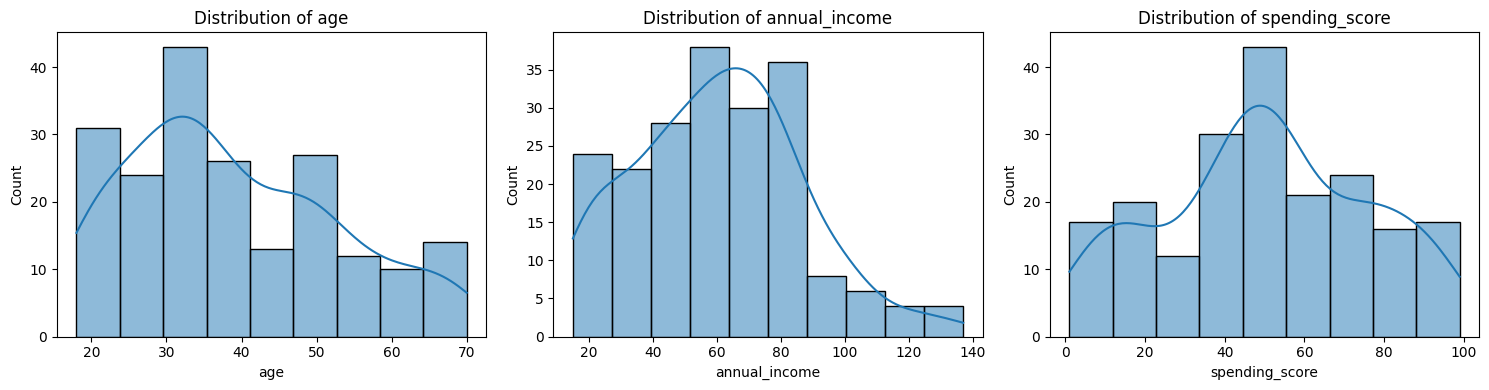

In [27]:
num_cols = ["age", "annual_income", "spending_score"]

plt.figure(figsize=(15, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.savefig("../images/numerical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


This step helps us understand the overall profile of the customer base. We analyze whether customers are concentrated in specific age groups, income ranges, or spending behavior levels.

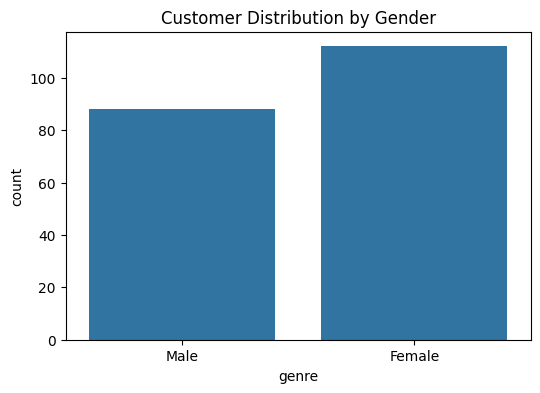

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="genre")
plt.title("Customer Distribution by Gender")
plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
df["genre"].value_counts(normalize=True) * 100

genre
Female    56.0
Male      44.0
Name: proportion, dtype: float64

Gender distribution helps us understand whether the customer base is balanced or concentrated in one group. However, gender alone should not define marketing decisions; it should be combined with behavioral and financial variables.

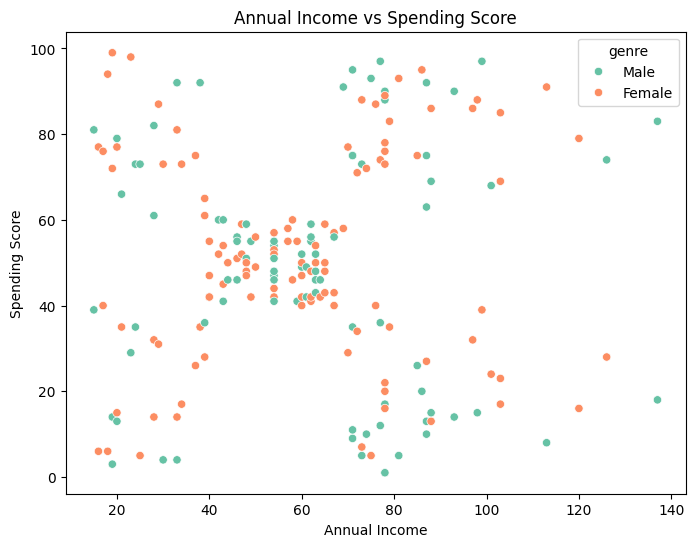

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="genre",
    palette="Set2"
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.savefig("../images/income_vs_spending_score.png", dpi=300, bbox_inches="tight")
plt.show()

The relationship between annual income and spending score is central to this project. Customers with similar income may behave very differently in terms of spending, which makes segmentation valuable for marketing strategy.

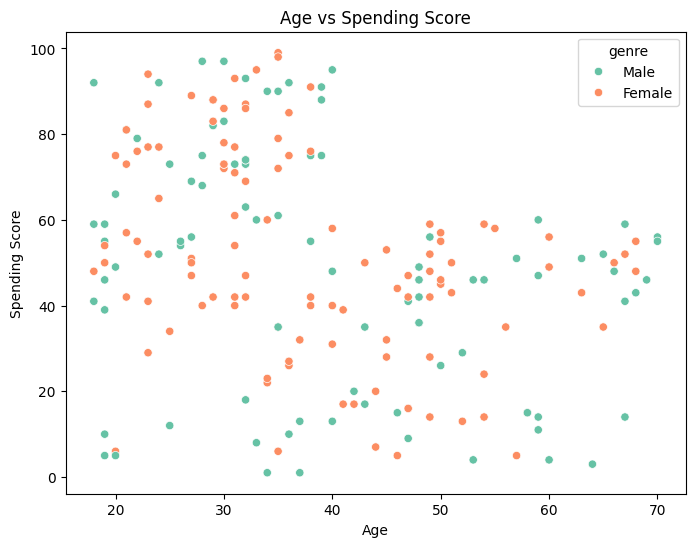

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="spending_score",
    hue="genre",
    palette="Set2"
)
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.savefig("../images/age_vs_spending_score.png", dpi=300, bbox_inches="tight")
plt.show()

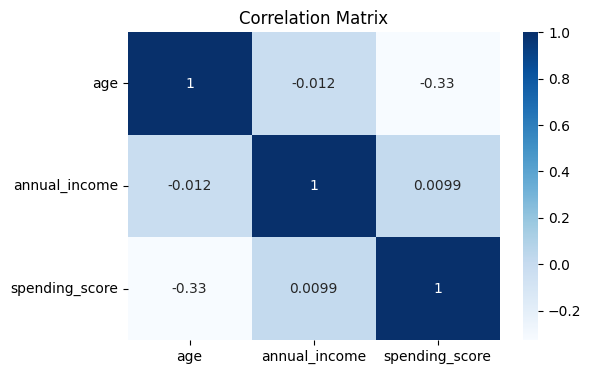

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation analysis gives an initial view of linear relationships between variables. However, clustering does not depend only on linear correlation; it groups customers based on similarity across selected features.

# 5. Feature Selection for Clustering

In [13]:
X = df[["annual_income", "spending_score"]]

In [14]:
X_full = df[["age", "annual_income", "spending_score"]]

# 6. Feature Scaling

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 7. Choosing K with Elbow Method

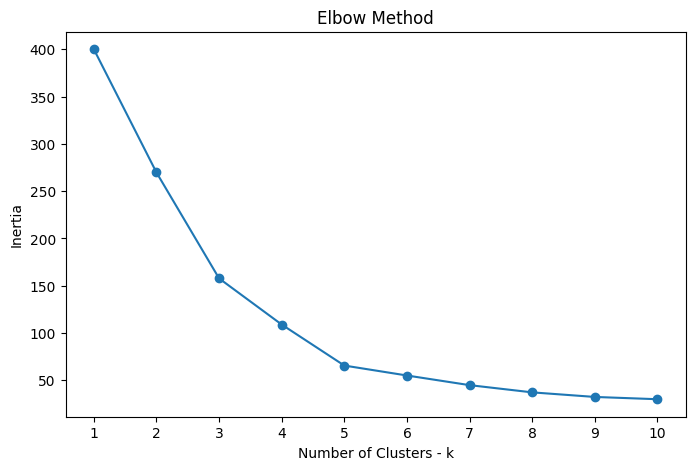

In [33]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters - k")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

The elbow method suggests the number of clusters where the reduction in inertia starts to slow down. In this dataset, the expected elbow is commonly around k = 5 when using Annual Income and Spending Score.

# 8. KMeans Modeling and Training

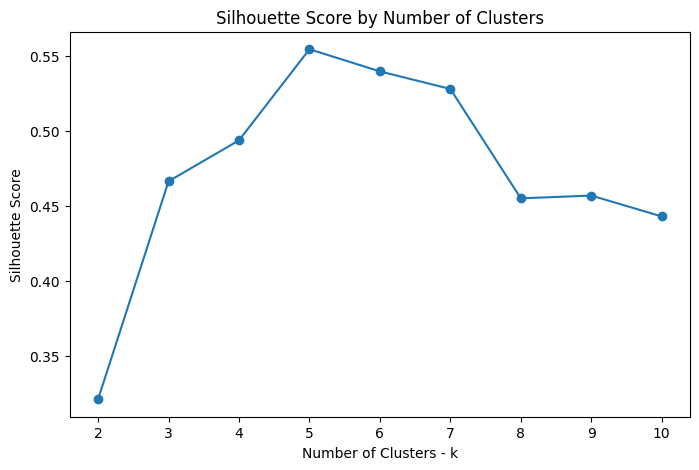

In [34]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters - k")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.savefig("../images/silhouette_score.png", dpi=300, bbox_inches="tight")
plt.show()

Silhouette Score helps evaluate how well-separated the clusters are. Higher values indicate better separation between clusters and greater similarity within the same cluster.

In [35]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,customerid,genre,age,annual_income,spending_score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# 9. Clusters Visualization and Profiling

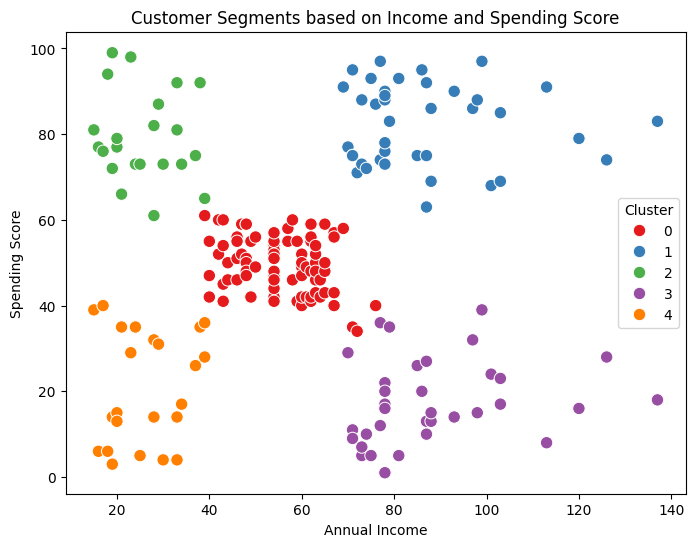

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="spending_score",
    hue="cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segments based on Income and Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.savefig("../images/customer_segments_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
cluster_profile = df.groupby("cluster").agg(
    customers=("customerid", "count"),
    avg_age=("age", "mean"),
    avg_income=("annual_income", "mean"),
    avg_spending_score=("spending_score", "mean")
).round(2)

cluster_profile

,customers,avg_age,avg_income,avg_spending_score
cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [21]:
cluster_profile["customer_share_%"] = (
    cluster_profile["customers"] / cluster_profile["customers"].sum() * 100
).round(2)

cluster_profile

,customers,avg_age,avg_income,avg_spending_score,customer_share_%
cluster,,,,,
0,81,42.72,55.30,49.52,40.5
1,39,32.69,86.54,82.13,19.5
2,22,25.27,25.73,79.36,11.0
3,35,41.11,88.20,17.11,17.5
4,23,45.22,26.30,20.91,11.5


In [22]:
gender_cluster = pd.crosstab(
    df["cluster"],
    df["genre"],
    normalize="index"
) * 100

gender_cluster.round(2)

genre,Female,Male
cluster,,
0,59.26,40.74
1,53.85,46.15
2,59.09,40.91
3,45.71,54.29
4,60.87,39.13


## Segment Naming

In [24]:
def segment_name(row):
    income = row["avg_income"]
    spending = row["avg_spending"]

    if income >= df["annual_income"].median() and spending >= df["spending_score"].median():
        return "High Income / High Spending"
    elif income >= df["annual_income"].median() and spending < df["spending_score"].median():
        return "High Income / Low Spending"
    elif income < df["annual_income"].median() and spending >= df["spending_score"].median():
        return "Low Income / High Spending"
    else:
        return "Low Income / Low Spending"

cluster_summary = df.groupby("cluster").agg(
    avg_age=("age", "mean"),
    avg_income=("annual_income", "mean"),
    avg_spending=("spending_score", "mean"),
    customers=("customerid", "count")
).reset_index()

cluster_summary["segment"] = cluster_summary.apply(segment_name, axis=1)

cluster_summary

,cluster,avg_age,avg_income,avg_spending,customers,segment
0,0,42.716049,55.296296,49.518519,81,Low Income / Low Spending
1,1,32.692308,86.538462,82.128205,39,High Income / High Spending
2,2,25.272727,25.727273,79.363636,22,Low Income / High Spending
3,3,41.114286,88.200000,17.114286,35,High Income / Low Spending
4,4,45.217391,26.304348,20.913043,23,Low Income / Low Spending


# 10. Business Interpretation

After applying KMeans clustering, each customer was assigned to a segment based on similarities in annual income and spending score.

The goal of this step is to translate numerical clusters into business-friendly customer profiles. This makes the results easier to understand and helps the marketing team design targeted actions for each group.

### Segment 1: High Income / High Spending

This segment represents customers with high annual income and high spending score.

These customers are likely the most valuable customers for the business. They have strong purchasing power and are already highly engaged with the mall.

**Business interpretation:**

- Premium customer profile
- High purchase potential
- Strong engagement with the mall
- Important group for loyalty and retention strategies

**Recommended marketing actions:**

- VIP loyalty program
- Early access to new collections or products
- Exclusive offers
- Personalized premium campaigns
- Invitations to special events

---

### Segment 2: High Income / Low Spending

This segment represents customers with high annual income but low spending score.

These customers have strong purchasing power, but they are not spending as much as expected. This group may represent an opportunity for activation, personalization, and relationship-building.

**Business interpretation:**

- High financial potential
- Low current engagement
- Possible lack of interest, poor targeting, or missing value perception
- Important segment for reactivation campaigns

**Recommended marketing actions:**

- Personalized offers based on preferences
- Premium product bundles
- Reactivation campaigns
- Customer surveys to understand barriers
- Retargeting campaigns
- Exclusive benefits to increase perceived value

---

### Segment 3: Low Income / High Spending

This segment represents customers with lower annual income but high spending score.

These customers may be highly engaged, promotion-sensitive, or frequent buyers. Even with lower income, they show strong spending behavior and can be valuable for loyalty strategies.

**Business interpretation:**

- Strong engagement
- Good response to promotions
- Potentially frequent shoppers
- Important group for retention, but campaigns should consider profitability

**Recommended marketing actions:**

- Cashback campaigns
- Discount coupons
- Loyalty points
- Seasonal promotions
- Installment options
- Bundle offers with accessible pricing

---

### Segment 4: Low Income / Low Spending

This segment represents customers with low annual income and low spending score.

These customers currently have lower business value compared to other groups. They may be more price-sensitive and less engaged with the mall.

**Business interpretation:**

- Low current spending potential
- Price-sensitive behavior
- Lower engagement
- Better suited for low-cost campaigns

**Recommended marketing actions:**

- Entry-level offers
- Basic discounts
- Awareness campaigns
- Low-cost product recommendations
- Seasonal or clearance promotions

---

### Segment 5: Medium Income / Medium Spending

This segment represents customers with moderate annual income and moderate spending score.

These customers behave close to the average customer profile. They may not be the highest priority, but they form a stable base that can be developed through cross-sell and loyalty actions.

**Business interpretation:**

- Stable customer base
- Average purchase behavior
- Moderate engagement
- Potential for gradual growth

**Recommended marketing actions:**

- Standard loyalty program
- Product recommendation campaigns
- Cross-sell opportunities
- Category-based promotions
- Personalized email campaigns

# 11. Conclusion

This project demonstrated how customer segmentation can support marketing decision-making in a retail environment.

Using KMeans clustering, we identified distinct customer groups based on income and spending behavior. These segments reveal different levels of business value, engagement, and growth potential.

The analysis shows that customer segmentation can help the business:
- personalize marketing campaigns;
- prioritize high-value customers;
- activate under-engaged customers;
- improve campaign ROI;
- support data-driven retail strategy.

## Next Steps

- Include purchase history and transaction frequency
- Add customer lifetime value estimation
- Test campaign response by segment
- Build a dashboard to monitor segment evolution
- Use RFM analysis if transaction-level data is available